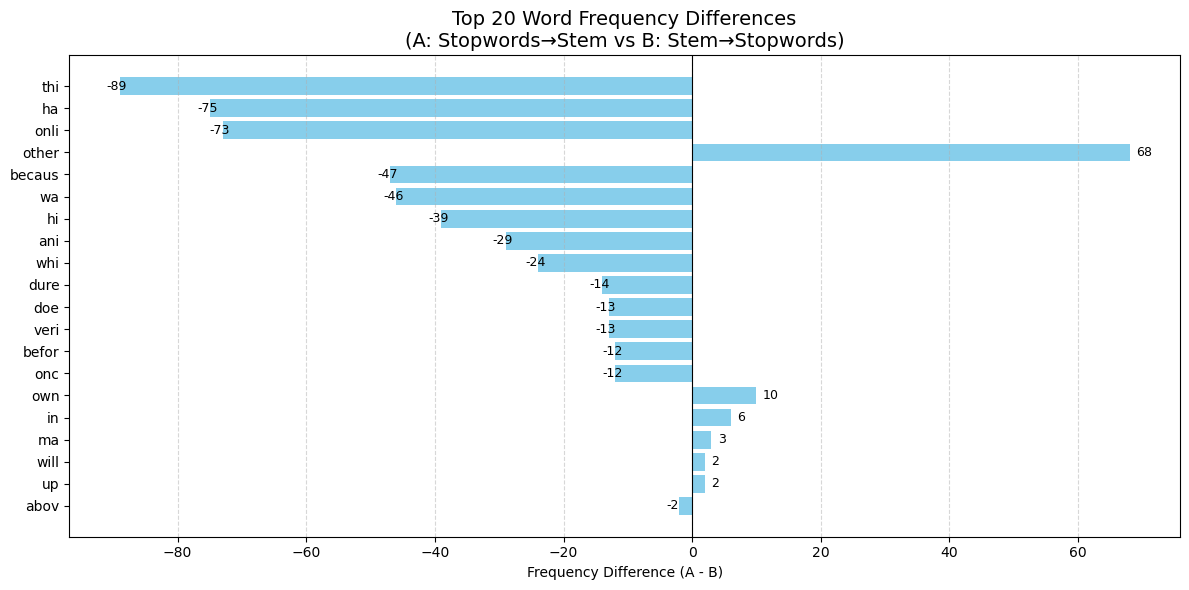

In [11]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("Data.csv", dtype=str)
df = df.fillna('')

# Combine all text into one large string
text = ' '.join(df.astype(str).apply(' '.join, axis=1))

# Tokenizer
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# ----- A: Stop word removal first, then stemming -----
tokens_A = tokenize(text)
filtered_A = [word for word in tokens_A if word not in stop_words]
normalized_A = [stemmer.stem(word) for word in filtered_A]
freq_A = Counter(normalized_A)

# ----- B: Stemming first, then stop word removal -----
tokens_B = tokenize(text)
normalized_B = [stemmer.stem(word) for word in tokens_B]
filtered_B = [word for word in normalized_B if word not in stop_words]
freq_B = Counter(filtered_B)

# Compare frequencies
all_words = set(freq_A.keys()).union(set(freq_B.keys()))
diff = {word: freq_A.get(word, 0) - freq_B.get(word, 0) for word in all_words}

# Sort by biggest absolute difference
sorted_diff = sorted(diff.items(), key=lambda x: abs(x[1]), reverse=True)

# Optional: filter only English (ASCII) words to avoid font warnings
# sorted_diff = [(w, d) for w, d in sorted_diff if all(ord(c) < 128 for c in w)]

# Set font to handle most Unicode characters
plt.rcParams['font.family'] = 'DejaVu Sans'

# Prepare data
top_n = 20
words = [w for w, _ in sorted_diff[:top_n]]
deltas = [d for _, d in sorted_diff[:top_n]]

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(words[::-1], deltas[::-1], color='skyblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Word Frequency Differences\n(A: Stopwords→Stem vs B: Stem→Stopwords)', fontsize=14)
plt.xlabel('Frequency Difference (A - B)')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Show values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (1 if width >= 0 else -2), bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=9)

plt.show()


# Impact of Removing Stopwords Before vs After Stemming

When stopwords are removed *before* stemming (Method A), potentially useful words are discarded before they even have a chance to be reduced to their root form.

**Example:** Words like “this” become “thi” and “has” becomes “ha” after stemming—but if these are removed as stopwords first, they never get stemmed at all.

**Result:** You lose meaningful root words, and word frequency counts drop significantly.

On the other hand, when stemming is done *before* stopword removal (Method B), **all** words—including stopwords—are stemmed first.

**Why it matters:** Even stopwords go through the stemming process, so you end up retaining more root forms.

**Result:** Better preservation of useful tokens and a more accurate frequency distribution.

## Conclusion
The order of preprocessing steps makes a big difference. Stemming *before* removing stopwords helps keep more information intact and leads to richer, more reliable data for downstream tasks.
